# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Student 1 | _your ID_ |
| Student 2 | _your ID_ |

# Deep RL in MiniGrid — Final Project (2026 B)

## Overview
Train **deep RL agents from scratch** — one from each of the value-based, policy-based, and actor-critic families —
on two image-based MiniGrid environments. The agent sees only the
**raw rendered RGB image** of the grid and must learn to act from pixels. No external RL libraries for the core
algorithms — use PyTorch / TensorFlow only for the neural networks.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the editable points; the PDF
defines what to deliver. The **report** is the primary deliverable and must be fully
self-contained: every graph, table, number, and discussion point lives there.

## Learning objectives
- Implement one algorithm from each family — **value-based** (e.g. DQN), **policy-based** (e.g. REINFORCE), and
  **actor-critic** (e.g. A2C) — from scratch, and compare them.
- Design observation preprocessing and reward shaping as composable wrappers.
- Choose hyperparameters and an exploration strategy deliberately, and justify them.
- Evaluate with clear metrics and plots, and communicate results in a concise report.

## The two environments
| Environment | Description | Win condition |
|---|---|---|
| **`SimpleRoomEnv`** | Empty 10×10 room (sanity check) | Step onto the green goal |
| **`ComplexEnv`** | Two rooms: key → locked door → water → lava → goal | Ferry water to extinguish the lava ring, then reach the goal |

Both expose the standard MiniGrid `Discrete(7)` action space and a **raw full-grid RGB observation** (`uint8`,
`H·tile × W·tile × 3`).

## What you build — and where
- **Observation preprocessing** — a `gym.ObservationWrapper` (e.g. grayscale, resize, channel-first, frame-stack).
- **Reward shaping** — a `gym.Wrapper` / `gym.RewardWrapper` that adds shaping on top of the sparse reward.
- **The agents** — for each family, the network(s), update rule, training loop, and evaluation (e.g. replay buffer
  + target net for DQN; a policy network for REINFORCE; actor + critic for A2C).

Do all of this **outside** the environments. Provided **example wrappers** and an **environment explorer** come first;
write your own wrappers and agents below the **"Your Code Below"** divider near the end. **The environment classes are
fixed**; see the full edit policy in the *Environments* section below.

## Reproducibility & integrity
- Seed Python, NumPy, and your DL framework, and document every hyperparameter.
- Submit (1) this notebook with all training/inference outputs and (2) the report PDF — a reader should understand your
  full methodology and results from the report alone.
- Discuss ideas freely, but code and write-up must be your own; cite any external resources (blog posts, papers, code).

# Setup

## Installs

In [30]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked for packages
# that aren't already importable, so re-running this cell is safe and cheap on both Colab
# and a local Python / venv kernel.
from __future__ import annotations

import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("numpy")
_ensure("matplotlib")
_ensure("cv2", "opencv-python")
_ensure("torch")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")   # mp4 backend for rollout videos
_ensure("ipywidgets")                          # inline env explorer (buttons)
# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [31]:
from __future__ import annotations

# Standard library
import base64
import os
import random
import sys
import time
from types import SimpleNamespace

# Numerics, plotting, video
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Notebook display helpers
from IPython.display import HTML, display

# Gymnasium + MiniGrid
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Ball, Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

# Image preprocessing + deep learning
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    try:
        import pyvirtualdisplay
        pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display] virtual display not started: {exc}")

%matplotlib inline
plt.rcParams["figure.figsize"] = (6.0, 5.0)

## Display utils
Save a rollout to an `.mp4` and embed it inline. Auto-detects Colab vs local Jupyter — no configuration needed.

In [32]:
def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename, max_steps=100, fps=10, seed=None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward, steps = 0.0, 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

# Environments — definition & construction

Two MiniGrid environments are defined below. **Both are fixed** — only `max_steps` may be overridden at
construction. Everything else (preprocessing, reward shaping, action restriction) goes in **wrappers**.

**Action IDs** (standard MiniGrid `Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° left (no move) |
| 1 | `right` | turn 90° right (no move) |
| 2 | `forward` | move one cell forward |
| 3 | `pickup` | pick up the object directly in front |
| 4 | `drop` | drop the carried object into the cell in front |
| 5 | `toggle` | activate the object in front (open a door with the matching key; **extinguish a lava tile while carrying water**) |
| 6 | `done` | no-op here |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` **downward**. Facing `agent_dir`:
`0`=right, `1`=down, `2`=left, `3`=up.

## Environment 1 — SimpleRoomEnv (sanity)

**Task.** Navigate from a random start to the green goal in an empty room.

| Property | Value |
|---|---|
| Grid | 10×10 (8×8 walkable) |
| Agent start | random interior cell, random facing |
| Goal | a random corner |
| Actions | `Discrete(7)` (only turn/forward are needed) |
| Reward | sparse: `+1` on the goal, `0` otherwise |
| Observation | raw full-grid RGB `uint8` |

In [33]:
# =============================================================================
# ENVIRONMENT 1: SimpleRoomEnv (empty room, sanity check)   --- FIXED, DO NOT EDIT
# =============================================================================
class SimpleRoomEnv(BaseMiniGridEnv):
    """Empty room: walk onto the green goal. Pass/fail sanity-check env.

    Same observation contract as ``ComplexEnv`` (raw full-grid RGB, uint8 HWC) and
    the standard MiniGrid ``Discrete(7)`` action space. Sparse reward ``+1`` on the
    goal. FIXED — wrap it to add preprocessing; you may only override ``max_steps``.
    """

    def __init__(self, width=10, height=10, max_steps=100, tile_size=4,
                 render_mode="rgb_array", **kwargs):
        assert width >= 4 and height >= 4
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ---
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )
        # --- per-episode layout: set by _gen_grid() ---
        self.goal_pos = None

    @staticmethod
    def _gen_mission():
        return "reach the green goal"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal in a random corner
        goal_x = int(self.np_random.choice([1, width - 2]))
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (goal_x, goal_y)
        self.put_obj(Goal(), goal_x, goal_y)

        # agent starts on any non-goal cell, facing a random direction
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))
        self.mission = self._gen_mission()

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(self.agent_pos) == tuple(self.goal_pos)

    def step(self, action):
        obs, _, _, truncated, info = super().step(action)
        terminated = self.is_on_goal()
        reward = 1.0 if terminated else 0.0
        return obs, reward, terminated, truncated, info

## Environment 2 — ComplexEnv (the task)

**Task — five stages: key → door → water → lava → goal.**
1. Pick up the **key** in the left room.
2. **Toggle** the locked partition **door** open (drop the key first if needed — only one object can be carried).
3. Pick up a **water ball** in the right room.
4. Face a **lava** tile and **toggle** to extinguish it; the tile clears and the ball is consumed. One ball per
   tile, so water must be **ferried repeatedly**.
5. Step onto the **goal** in the lava-ringed corner. Stepping on un-extinguished lava is **lethal**.

Objects may spawn in your path — the agent must learn to move them out of the way.

| Property | Value |
|---|---|
| Grid | 10×10, two rooms split by a partition wall (`partition_col=3`) |
| Agent start | `(1, 1)`, random facing |
| Key / Door | one key at a random left-room cell; one locked door at a random partition row |
| Water balls | a contiguous cluster in the top or bottom left of the right room (`water_corner`) |
| Lava | rings the goal corner; lethal until extinguished |
| Goal | top or bottom right-room corner (`goal_corner`) |
| Actions | `Discrete(7)` (turn / forward / pickup / drop / toggle all matter) |
| Reward | sparse: `+1` on the goal, `0` otherwise; lava death ends the episode with `0` |
| Observation | raw full-grid RGB `uint8` |

**Helper getters.** The observation is raw RGB, so there is no tabular state to read. `ComplexEnv` exposes
`is_*` / `prev_*` getters (current vs. start-of-step) plus position getters — see the class docstring (next
code cell) for the full list. They exist for wrappers (event detection) and analysis; reward may **not** use
geometry or distance.

**`info` dict** (from `step` / `reset`): `is_success`, `died_on_lava`, `extinguished_lava_count`, `n_lava`,
`extinguished_this_step`.

In [34]:
# =============================================================================
# ENVIRONMENT 2: ComplexEnv (key -> door -> water -> lava -> goal)  --- FIXED, DO NOT EDIT
# =============================================================================
class ComplexEnv(BaseMiniGridEnv):
    """Key -> door -> water -> lava -> goal (image-based, sparse reward).

    The left room holds a single locked-door key; the right room holds the goal in
    a top or bottom right corner ringed by lethal ``Lava`` (the ring mirrors with
    the corner), plus several ``Ball`` "water" objects.
    To win: pick up the key, toggle the locked door open, drop the key (only one
    object can be carried), pick up a water ball, ``toggle`` it while facing a lava
    tile (extinguishes that tile and consumes the ball) -- ferrying water until the
    path is clear -- then step onto the goal. Stepping on un-extinguished lava is lethal.

    Observation: raw full-grid RGB ``(H*tile, W*tile, 3)`` uint8. Reward: sparse
    ``+1`` on the goal, ``0`` otherwise. FIXED -- wrap it to add preprocessing / reward
    shaping; you may only override ``max_steps``.


    Helper getters -- for event-based reward shaping and for evaluation / EDA. (The
    observation is the raw RGB image, so there is no tabular "state" to read here; and
    reward may NOT depend on geometry / distance, so the position getters are for
    analysis, not for shaping.)
      curr (now)            : is_carrying_key / is_carrying_water / is_door_open /
                              is_door_locked / is_on_lava / is_on_goal / is_in_right_room /
                              extinguished_lava_count
      prev (start of step)  : prev_carrying_key / prev_carrying_water / prev_door_open /
                              prev_door_locked / prev_in_right_room / prev_extinguished_lava_count
      positions (eval & EDA): key_position / water_positions / lava_positions
    Detect an event as *curr and not prev*, e.g.
    just picked up water == ``is_carrying_water() and not prev_carrying_water()``.
    Latch a milestone ("ever opened the door") yourself in your wrapper if you want one.
    """

    def __init__(self, max_steps=400, width=10, height=10, tile_size=32,
                 render_mode="rgb_array", partition_col=3,
                 agent_start_pos=(1, 1), goal_corner="random",
                 n_water=3, water_corner="random",
                 key_door_color="purple", water_color="blue", **kwargs):
        assert width >= 8 and height >= 5
        assert 2 <= partition_col < width - 2   # leave >=1 right-room column for the goal
        assert goal_corner in ("top", "bottom", "random")
        assert water_corner in ("top", "bottom", "random")
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ----------------
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )

        # --- task configuration: fixed for the env's lifetime (from constructor args) --
        self.partition_col = partition_col
        self.key_color = key_door_color
        self.door_color = key_door_color
        self.water_color = water_color
        self.n_water = int(n_water)
        self.goal_corner = goal_corner           # "top" / "bottom" / "random" (resolved per episode)
        self.water_corner = water_corner         # "top" / "bottom" / "random" (resolved per episode)
        # agent start: None -> randomized per episode; otherwise reused each episode.
        self.fixed_agent_start_pos = (None if agent_start_pos is None
                                      else tuple(int(v) for v in agent_start_pos))

        # --- per-episode layout: (re)filled by _gen_grid() on every reset ---------------
        self.door_pos = None
        self.goal_pos = None
        self.lava_ring = ()                 # ring around the goal corner (mirrors it)
        self._door = None

        # --- episode progress: count of lava tiles extinguished so far this episode -----
        self._extinguished_lava_count = 0

        # --- previous-step snapshot: each value as of the START of the current step ------
        self._prev_carrying_key = False
        self._prev_carrying_water = False
        self._prev_door_open = False
        self._prev_door_locked = False
        self._prev_in_right_room = False
        self._prev_extinguished_lava_count = 0

    @staticmethod
    def _gen_mission():
        return "get the key, open the door, extinguish the lava with water, then reach the goal"

    def _resolve_corner(self, mode):
        """Resolve a 'top'/'bottom'/'random' corner mode to a concrete 'top'/'bottom'
        for this episode ('random' is re-rolled every episode via the env RNG)."""
        if mode == "random":
            return "top" if int(self.np_random.integers(0, 2)) == 0 else "bottom"
        return mode

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting left (key) from right (goal + lava + water)
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random partition row
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.door_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # agent start: fixed if provided, else a random left-room cell, facing random
        if self.fixed_agent_start_pos is not None:
            self.agent_pos = self.fixed_agent_start_pos
        else:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        # the single key on a left-room cell (never UNDER the agent). It MAY land on the
        # door-approach cell -- no clearance is reserved, so it can block the way.
        blocked = {tuple(self.agent_pos)}
        left_cells = [(x, y) for x in range(1, self.partition_col)
                      for y in range(1, height - 1) if (x, y) not in blocked]
        kx, ky = left_cells[int(self.np_random.integers(len(left_cells)))]
        self.grid.set(kx, ky, Key(self.key_color))

        # goal in a right-room corner (top or bottom); the lava ring mirrors with it so
        # it always cups the goal corner. The goal stays in the far-right column (x=width-2).
        goal_corner = self._resolve_corner(self.goal_corner)
        gx = width - 2
        if goal_corner == "bottom":
            self.goal_pos = (gx, height - 2)
            self.lava_ring = ((gx - 1, height - 2), (gx, height - 3), (gx - 1, height - 3))
        else:  # top: vertical mirror of the bottom ring
            self.goal_pos = (gx, 1)
            self.lava_ring = ((gx - 1, 1), (gx, 2), (gx - 1, 2))
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # lethal lava ringing the goal corner
        for lx, ly in self.lava_ring:
            self.grid.set(lx, ly, Lava())

        # water balls: a contiguous cluster on the top or bottom row (water_corner), starting
        # at the left edge of the right room. Cells overlapping the goal/lava are skipped, so a
        # large n_water relative to the room width may place fewer than n_water balls.
        water_corner = self._resolve_corner(self.water_corner)
        wy = 1 if water_corner == "top" else height - 2
        reserved = {tuple(self.goal_pos)} | set(self.lava_ring)
        placements = []
        for i in range(self.n_water):
            wx = self.partition_col + 1 + i
            if wx > width - 2:
                break
            if (wx, wy) not in reserved:
                placements.append((wx, wy))
        for wx, wy in placements:
            self.grid.set(wx, wy, Ball(self.water_color))

        # reset the per-episode extinguished-lava count (the prev snapshot is taken in
        # reset, once the base class has finished setting up self.carrying etc.)
        self._extinguished_lava_count = 0
        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)   # calls _gen_grid()
        self._snapshot_prev()                                   # prev == the fresh reset state
        info = dict(info)
        info.update(self._info_snapshot(terminated=False, extinguished_now=0))
        return obs, info

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    # ============================ curr: instantaneous state (true only RIGHT NOW) =======
    def is_carrying_key(self) -> bool:
        """True iff a key is in hand right now."""
        return isinstance(self.carrying, Key)

    def is_carrying_water(self) -> bool:
        """True iff a water ball is in hand right now."""
        return isinstance(self.carrying, Ball)

    def is_door_open(self) -> bool:
        """True iff the door is open right now."""
        return bool(self._door is not None and self._door.is_open)

    def is_door_locked(self) -> bool:
        """True iff the door is locked right now (opening it unlocks it for good)."""
        return bool(self._door is not None and self._door.is_locked)

    def is_on_lava(self) -> bool:
        """True iff the agent is standing on a lava tile right now (a lethal lava death)."""
        return isinstance(self.grid.get(int(self.agent_pos[0]), int(self.agent_pos[1])), Lava)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(int(v) for v in self.agent_pos) == tuple(int(v) for v in self.goal_pos)

    def is_in_right_room(self) -> bool:
        """True iff the agent is past the partition wall (right room)."""
        return int(self.agent_pos[0]) > self.partition_col

    def extinguished_lava_count(self) -> int:
        """How many lava tiles have been extinguished so far this episode (only grows)."""
        return self._extinguished_lava_count

    # ============================ prev: same state, as of the START of this step ========
    def prev_carrying_key(self) -> bool: return self._prev_carrying_key
    def prev_carrying_water(self) -> bool: return self._prev_carrying_water
    def prev_door_open(self) -> bool: return self._prev_door_open
    def prev_door_locked(self) -> bool: return self._prev_door_locked
    def prev_in_right_room(self) -> bool: return self._prev_in_right_room
    def prev_extinguished_lava_count(self) -> int: return self._prev_extinguished_lava_count

    # ============================ positions / layout: for evaluation / EDA ==============
    def key_position(self) -> tuple[int, int] | None:
        """The single key's (x, y) while uncarried, else None (its color is ``key_color``)."""
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    return (x, y)
        return None

    def water_positions(self) -> list:
        """Remaining (uncarried) water balls on the grid."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Ball)]

    def lava_positions(self) -> list:
        """Lava tiles still present (not yet extinguished)."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Lava)]

    # ============================ internal bookkeeping ==================================
    def _snapshot_prev(self):
        """Capture the instantaneous state so the prev_* getters describe the value as
        of the START of the next step (i.e. the last step's value)."""
        self._prev_carrying_key = self.is_carrying_key()
        self._prev_carrying_water = self.is_carrying_water()
        self._prev_door_open = self.is_door_open()
        self._prev_door_locked = self.is_door_locked()
        self._prev_in_right_room = self.is_in_right_room()
        self._prev_extinguished_lava_count = self._extinguished_lava_count

    def _faced_lava_to_extinguish(self, action):
        """Return the (x, y) of the lava tile this action would extinguish -- i.e.
        ``toggle`` while carrying water and facing lava -- or None. (Base MiniGrid has
        no toggle behaviour for lava, so we resolve it ourselves.)"""
        if int(action) != int(self.actions.toggle) or not isinstance(self.carrying, Ball):
            return None
        fx, fy = (int(v) for v in self.front_pos)
        return (fx, fy) if isinstance(self.grid.get(fx, fy), Lava) else None

    def _resolve_goal(self, terminated):
        """Win (+1, terminate) on the goal cell; otherwise keep the base ``terminated``
        so a step onto un-extinguished lava stays lethal (death ends with no reward)."""
        if self.is_on_goal():
            return 1.0, True
        return 0.0, terminated

    def _info_snapshot(self, *, terminated, extinguished_now):
        """Ground-truth signals the env owns, surfaced through ``info`` for logging /
        evaluation."""
        return {
            "extinguished_lava_count": int(self._extinguished_lava_count),
            "n_lava": len(self.lava_ring),
            "extinguished_this_step": int(extinguished_now),
            "is_success": bool(self.is_on_goal()),
            "died_on_lava": bool(terminated and not self.is_on_goal()),
        }

    # ============================ step / reward =========================================
    def step(self, action):
        self._snapshot_prev()   # 'prev' = state as of the start of this step

        extinguish_target = self._faced_lava_to_extinguish(action)
        obs, _, terminated, truncated, info = super().step(action)

        extinguished_now = 0
        if extinguish_target is not None:
            ex, ey = extinguish_target
            self.grid.set(ex, ey, None)     # lava -> empty floor
            self.carrying = None            # the water ball is consumed
            self._extinguished_lava_count += 1
            extinguished_now = 1
            obs = self.gen_obs()            # refresh the image after the change

        reward, terminated = self._resolve_goal(terminated)

        info = dict(info)
        info.update(self._info_snapshot(terminated=terminated, extinguished_now=extinguished_now))
        return obs, reward, terminated, truncated, info

# Environment exploration

Get a feel for both envs before building anything — inspect the API and getters, the initial state, and a
random-action rollout. Nothing here is graded.

=== SimpleRoomEnv ===
obs shape / dtype : (40, 40, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (6, 4)  dir=1
goal_pos          : (1, 8)
info              : {}

=== ComplexEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (1, 1)  dir=3
door color / pos  : purple  (3, 1)
goal_pos          : (8, 1)
key   position    : (2, 3)  color=purple
water positions   : [(4, 1), (5, 1), (6, 1)]
lava  positions   : [(7, 1), (7, 2), (8, 2)]
-- curr state at reset --
carrying_key=False  carrying_water=False  in_right_room=False
door_open=False  door_locked=True  on_lava=False  on_goal=False
extinguished lava tiles : 0
info keys          : ['died_on_lava', 'extinguished_lava_count', 'extinguished_this_step', 'is_success', 'n_lava']


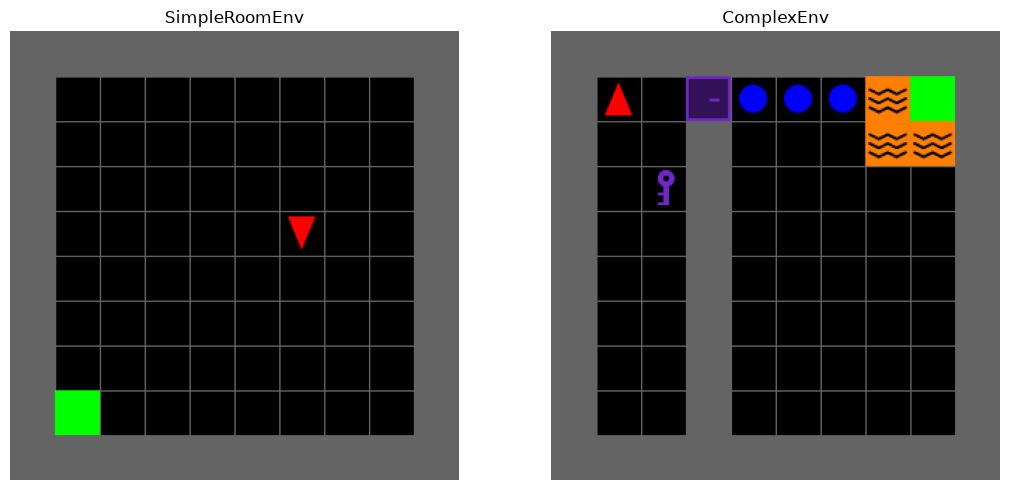

In [35]:
# Environment info + initial-state render for both envs, side by side.
simple_env = SimpleRoomEnv(max_steps=100)
s_obs, s_info = simple_env.reset(seed=42)

env = ComplexEnv(max_steps=400)
c_obs, c_info = env.reset(seed=42)

print("=== SimpleRoomEnv ===")
print(f"obs shape / dtype : {s_obs.shape}  {s_obs.dtype}")
print(f"action space      : {simple_env.action_space}")
print(f"agent pos / dir   : {simple_env.agent_pos}  dir={simple_env.agent_dir}")
print(f"goal_pos          : {simple_env.goal_pos}")
print(f"info              : {s_info}")

print("\n=== ComplexEnv ===")
print(f"obs shape / dtype : {c_obs.shape}  {c_obs.dtype}")
print(f"action space      : {env.action_space}")
print(f"agent pos / dir   : {env.agent_pos}  dir={env.agent_dir}")
print(f"door color / pos  : {env.door_color}  {env.door_pos}")
print(f"goal_pos          : {env.goal_pos}")
print(f"key   position    : {env.key_position()}  color={env.key_color}")
print(f"water positions   : {env.water_positions()}")
print(f"lava  positions   : {env.lava_positions()}")
print("-- curr state at reset --")
print(f"carrying_key={env.is_carrying_key()}  carrying_water={env.is_carrying_water()}  "
      f"in_right_room={env.is_in_right_room()}")
print(f"door_open={env.is_door_open()}  door_locked={env.is_door_locked()}  "
      f"on_lava={env.is_on_lava()}  on_goal={env.is_on_goal()}")
print(f"extinguished lava tiles : {env.extinguished_lava_count()}")
print(f"info keys          : {sorted(c_info)}")

# Initial-state render, both envs side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, e, title in ((axes[0], simple_env, "SimpleRoomEnv"), (axes[1], env, "ComplexEnv")):
    ax.imshow(e.render())
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

In [36]:
# Random-action rollouts for both envs, shown side by side.
# (Random actions rarely make progress on either env -- that's expected.)
simple_video = video_path("SimpleRoomEnv_random.mp4")
s_steps, s_total = random_rollout_video(simple_env, simple_video, max_steps=100, seed=1)
print(f"SimpleRoomEnv random rollout: steps={s_steps}, total_reward={s_total:.2f}")

complex_video = video_path("ComplexEnv_random.mp4")
c_steps, c_total = random_rollout_video(env, complex_video, max_steps=100, seed=1)
print(f"ComplexEnv  random rollout: steps={c_steps}, total_reward={c_total:.2f}")


def _b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


display(HTML(f"""
<div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
  <figure style="margin:0; text-align:center;">
    <figcaption><b>SimpleRoomEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(simple_video)}" type="video/mp4">
    </video>
  </figure>
  <figure style="margin:0; text-align:center;">
    <figcaption><b>ComplexEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(complex_video)}" type="video/mp4">
    </video>
  </figure>
</div>
"""))

SimpleRoomEnv random rollout: steps=100, total_reward=0.00
ComplexEnv  random rollout: steps=100, total_reward=0.00


# Preprocessing & reward shaping — via wrappers

Everything outside the fixed envs is done with Gymnasium wrappers:

- **Observation preprocessing** → `gym.ObservationWrapper` (override `observation(obs)`, update `observation_space`).
- **Reward shaping** → `gym.Wrapper` / `gym.RewardWrapper` (modify the reward in `step`, reading the env getters).
- **Action subset** → `gym.ActionWrapper` (restrict the 7 actions).

Wrappers compose, e.g. `GrayscaleWrapper(ShapingWrapper(ComplexEnv()))`; reach the base env via `env.unwrapped`.
The next cell provides three **example wrappers** as starting points.

## Example wrappers (starter code)

Three minimal examples to build on:
1. `GrayscaleWrapper` — RGB → single-channel grayscale.
2. `EventShapingWrapper` — scale the sparse goal reward and add a one-off event bonus via the env getters.
3. `ActionSubsetWrapper` — expose only a subset of the actions.

In [37]:
class GrayscaleWrapper(gym.ObservationWrapper):
    """Example: convert the raw RGB observation (H, W, 3) to grayscale (H, W, 1)."""

    def __init__(self, env):
        super().__init__(env)
        h, w, _ = env.observation_space.shape
        self.observation_space = spaces.Box(low=0, high=255, shape=(h, w, 1), dtype=np.uint8)

    def observation(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return gray[:, :, None]   # (H, W) -> (H, W, 1)

In [38]:
class EventShapingWrapper(gym.Wrapper):
    """Example: scale the sparse env reward and add tiny event-based shaping."""

    def __init__(self, env, base_reward_scale: float = 10.0,
                 door_bonus: float = 1.0, step_penalty: float = 0.01):
        super().__init__(env)
        self.base_reward_scale = float(base_reward_scale)
        self.door_bonus = float(door_bonus)
        self.step_penalty = float(step_penalty)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        core_env = self.env.unwrapped
        reward = self.base_reward_scale * float(reward) - self.step_penalty
        if core_env.is_door_open() and not core_env.prev_door_open():   # door just opened
            reward += self.door_bonus
        return obs, reward, terminated, truncated, info

In [39]:
class ActionSubsetWrapper(gym.ActionWrapper):
    """Example: expose only a chosen subset of the 7 MiniGrid actions as a smaller,
    contiguous Discrete space. The agent picks an index ``0..k-1`` and the wrapper
    maps it back to the real MiniGrid action id. Dropping actions the task never needs
    (e.g. ``done``) shrinks the space the agent has to explore.
    """

    def __init__(self, env, action_ids=(0, 1, 2, 3, 4, 5)):
        super().__init__(env)
        self.action_ids = tuple(int(a) for a in action_ids)
        self.action_space = spaces.Discrete(len(self.action_ids))

    def action(self, act):
        return self.action_ids[int(act)]   # policy index -> real MiniGrid action id

wrapped obs shape / dtype : (320, 320, 1)  uint8
observation_space         : Box(0, 255, (320, 320, 1), uint8)
action_space              : Discrete(6)  (subset of the 7 MiniGrid actions)


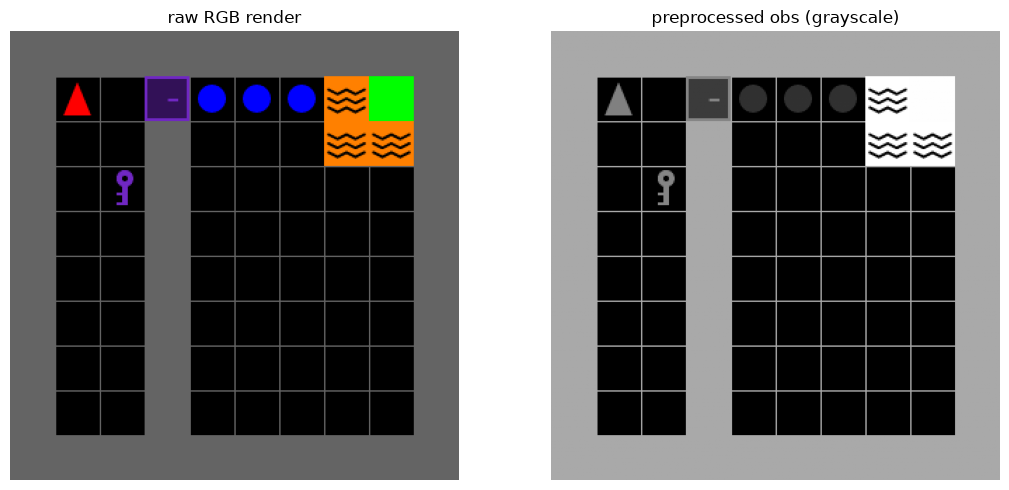

In [40]:
# Compose the example wrappers and inspect the result. Order matters.
demo = ComplexEnv(max_steps=400)
demo = EventShapingWrapper(demo, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
demo = ActionSubsetWrapper(demo, action_ids=(0, 1, 2, 3, 4, 5))
demo = GrayscaleWrapper(demo)

obs, info = demo.reset(seed=42)
print(f"wrapped obs shape / dtype : {obs.shape}  {obs.dtype}")
print(f"observation_space         : {demo.observation_space}")
print(f"action_space              : {demo.action_space}  (subset of the 7 MiniGrid actions)")

raw = demo.unwrapped.render()                       # full-color render of the same state
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(raw); axes[0].set_title("raw RGB render"); axes[0].axis("off")
axes[1].imshow(obs.squeeze(), cmap="gray")
axes[1].set_title("preprocessed obs (grayscale)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Environment explorer (drive an env by hand)

Step an env one action at a time with buttons, rendered inline, watching the reward, getters, and status
flags update. Point it at a **wrapped** env to see your shaped / scaled reward and preprocessed pipeline
(state read-outs come from `env.unwrapped`).

**Requires** `ipywidgets` and `env_explorer.py` in the working directory (in Colab, drag the file into
the **Files** panel). Safe to skip if a dependency is missing. Re-run after editing an env or a wrapper.

In [41]:
# Optional manual driver. Drive a *wrapped* env by hand to watch shaped reward + getters as you act.
# (Pass `ComplexEnv` instead for the bare env.) On Colab: drag env_explorer.py into Files first.
def make_explore_env():
    env = ComplexEnv(max_steps=400)
    env = EventShapingWrapper(env, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
    env = GrayscaleWrapper(env)
    return env


try:
    from env_explorer import explore_env
    explore_env(make_explore_env, seed=None)        # or explore_env(ComplexEnv) for the raw env
except Exception as exc:
    print(f"[explorer] not started: {exc}")

# Your Code Below

Everything below is yours — add as many cells as you need. Build your wrappers and agents here; see the PDF
for the deliverables. Good luck!

## Device

In [42]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


## Algorithms

Shared agent interface in `algorithms/`. **DQN** is implemented; REINFORCE / A2C come later.

- `BaseAlgorithm` — common `select_action` / `train` / `evaluate` / `save` / `load`
- `DQN` — CNN Q-network, replay buffer, target net, ε-greedy


In [47]:
import importlib
import algorithms
importlib.reload(algorithms)
importlib.reload(algorithms.base)
importlib.reload(algorithms.dqn)

from algorithms import BaseAlgorithm, DQN

print(BaseAlgorithm)
print(DQN)


<class 'algorithms.base.BaseAlgorithm'>
<class 'algorithms.dqn.DQN'>


### DQN — sanity check on `SimpleRoomEnv`

Train a short DQN run on the empty room (grayscale + action subset). Scale up `total_timesteps` and move to `ComplexEnv` once this learns.


In [49]:
def make_simple_env():
    env = SimpleRoomEnv(max_steps=100, tile_size=4)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2))  # left / right / forward enough for empty room
    env = GrayscaleWrapper(env)
    return env


def agent_rollout_video(agent, env, filename, max_steps=100, fps=8, seed=None):
    """One greedy episode under ``agent``; save mp4 and return (steps, total_reward)."""
    obs, _ = env.reset(seed=seed)
    total_reward, steps = 0.0, 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = agent.select_action(obs, explore=False)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward


_probe = make_simple_env()
obs_shape = _probe.observation_space.shape
n_actions = _probe.action_space.n
_probe.close()

dqn = DQN(
    obs_shape,
    n_actions,
    device=device,
    seed=0,
    gamma=0.99,
    lr=1e-4,
    batch_size=64,
    buffer_size=50_000,
    learning_starts=1_000,
    train_freq=4,
    target_update_freq=500,
    eps_start=1.0,
    eps_end=0.05,
    eps_decay_steps=20_000,
)
print(dqn)

# Short smoke run — bump total_timesteps for a real experiment.
dqn_history = dqn.train(make_simple_env, total_timesteps=5_000, log_every=1_000)

eval_env = make_simple_env()
print("eval:", dqn.evaluate(eval_env, n_episodes=5, seed=100))
eval_env.close()

# Greedy policy video after the smoke run.
dqn_video = video_path("dqn_simple_room.mp4")
vid_env = make_simple_env()
v_steps, v_return = agent_rollout_video(dqn, vid_env, dqn_video, max_steps=100, seed=42)
vid_env.close()
print(f"video: {dqn_video}  steps={v_steps}  return={v_return:.2f}")
embed_mp4(dqn_video)


DQN(obs_shape=(40, 40, 1), n_actions=3, device=mps, steps=0)
steps=   1833  episodes=   20  return=   0.00  mean20=   0.10  eps=0.913
steps=   3727  episodes=   40  return=   0.00  mean20=   0.15  eps=0.823
eval: {'mean_return': 0.0, 'std_return': 0.0, 'mean_length': 100.0, 'n_episodes': 5.0}
video: /Users/EyalsMac/University/Masters/Reinforcment Learning/Final Project/RLEX3/videos/dqn_simple_room.mp4  steps=100  return=0.00
